# Import The Library

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Read The Zepto Files

In [3]:
zep=pd.read_csv(r"C:\Users\SHUSHREE SWAIN\OneDrive\Desktop\Zepto\zepto_sales_dataset.csv")
zep

,Product_Name,Category,City,Original_Price,Current_Price,Discount,Orders,Total_Revenue,Influencer_Active
0,Britannia Cake,Snacks,Delhi,148,163,5,283,44714,No
1,Britannia Cake,Snacks,Pune,81,86,10,284,21584,Yes
2,Fortune Oil 1L,Grocery,Hyderabad,138,143,10,69,9177,No
3,Pepsi 500ml,Beverages,Delhi,127,127,10,83,9711,No
4,Aashirvaad Atta,Grocery,Chennai,34,49,10,169,6591,Yes
...,...,...,...,...,...,...,...,...,...
295,Britannia Cake,Snacks,Pune,198,198,5,52,10036,Yes
296,Amul Milk 500ml,Dairy,Hyderabad,131,146,10,146,19856,No
297,Oreo Biscuits,Snacks,Delhi,171,176,10,291,48306,No
298,Amul Milk 500ml,Dairy,Mumbai,94,99,0,124,12276,No


In [4]:
zep.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Product_Name       300 non-null    object
 1   Category           300 non-null    object
 2   City               300 non-null    object
 3   Original_Price     300 non-null    int64 
 4   Current_Price      300 non-null    int64 
 5   Discount           300 non-null    int64 
 6   Orders             300 non-null    int64 
 7   Total_Revenue      300 non-null    int64 
 8   Influencer_Active  300 non-null    object
dtypes: int64(5), object(4)
memory usage: 21.2+ KB


In [5]:
zep.dtypes

Product_Name         object
Category             object
City                 object
Original_Price        int64
Current_Price         int64
Discount              int64
Orders                int64
Total_Revenue         int64
Influencer_Active    object
dtype: object

In [6]:
zep.isnull().sum()

Product_Name         0
Category             0
City                 0
Original_Price       0
Current_Price        0
Discount             0
Orders               0
Total_Revenue        0
Influencer_Active    0
dtype: int64

In [7]:
z=zep.describe(include='all')
z

,Product_Name,Category,City,Original_Price,Current_Price,Discount,Orders,Total_Revenue,Influencer_Active
count,300,300,300,300.000000,300.000000,300.000000,300.000000,300.000000,300
unique,10,6,6,NaN,NaN,NaN,NaN,NaN,2
top,Maggi Noodles,Snacks,Hyderabad,NaN,NaN,NaN,NaN,NaN,No
freq,36,82,60,NaN,NaN,NaN,NaN,NaN,210
mean,NaN,NaN,NaN,111.866667,119.200000,4.916667,168.153333,19277.836667,NaN
std,NaN,NaN,NaN,49.936102,50.462543,4.179468,74.258541,12744.470724,NaN
min,NaN,NaN,NaN,20.000000,21.000000,0.000000,50.000000,1392.000000,NaN
25%,NaN,NaN,NaN,71.750000,78.000000,0.000000,103.750000,9025.250000,NaN
50%,NaN,NaN,NaN,115.000000,120.500000,5.000000,161.500000,16227.000000,NaN
75%,NaN,NaN,NaN,151.500000,161.000000,10.000000,233.750000,27396.000000,NaN


# Data Cleaning

In [8]:
# Drop duplicates
zep.drop_duplicates(inplace=True)

# Convert columns to correct data types (if needed)
zep['Original_Price'] = pd.to_numeric(zep['Original_Price'], errors='coerce')
zep['Discount'] = pd.to_numeric(zep['Discount'], errors='coerce')
zep['Orders'] = pd.to_numeric(zep['Orders'], errors='coerce')
zep['Total_Revenue'] = pd.to_numeric(zep['Total_Revenue'], errors='coerce')

# Discount %

In [9]:
zep['Discount_%'] = ((zep['Original_Price'] - zep['Current_Price']) / zep['Original_Price']) * 100

# Revenue per Order

In [10]:
zep['Revenue_per_order'] = zep['Total_Revenue'] / zep['Orders']

# Influencer flag

In [11]:
zep['Influencer_flag'] = zep['Influencer_Active'].map({'Yes': 1, 'No': 0})

In [12]:
zep[zep['Current_Price'] > zep['Original_Price']]

,Product_Name,Category,City,Original_Price,Current_Price,Discount,Orders,Total_Revenue,Influencer_Active,Discount_%,Revenue_per_order,Influencer_flag
0,Britannia Cake,Snacks,Delhi,148,163,5,283,44714,No,-10.135135,158.0,0
1,Britannia Cake,Snacks,Pune,81,86,10,284,21584,Yes,-6.172840,76.0,1
2,Fortune Oil 1L,Grocery,Hyderabad,138,143,10,69,9177,No,-3.623188,133.0,0
4,Aashirvaad Atta,Grocery,Chennai,34,49,10,169,6591,Yes,-44.117647,39.0,1
5,Amul Milk 500ml,Dairy,Delhi,149,159,0,246,39114,No,-6.711409,159.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
293,Maggi Noodles,Instant Food,Pune,125,140,0,283,39620,Yes,-12.000000,140.0,1
294,Parle-G,Snacks,Bangalore,134,144,0,190,27360,Yes,-7.462687,144.0,1
296,Amul Milk 500ml,Dairy,Hyderabad,131,146,10,146,19856,No,-11.450382,136.0,0
297,Oreo Biscuits,Snacks,Delhi,171,176,10,291,48306,No,-2.923977,166.0,0


# Key Analysis

# Revenue By category

In [13]:
zep.groupby('Category')['Total_Revenue'].sum().sort_values(ascending=False)

Category
Snacks           1712447
Beverages        1227002
Grocery           955353
Instant Food      661477
Confectionery     647424
Dairy             579648
Name: Total_Revenue, dtype: int64

# Discount vs Revenue

In [14]:
zep[['Discount_%', 'Total_Revenue']].corr()

,Discount_%,Total_Revenue
Discount_%,1.000000,0.285418
Total_Revenue,0.285418,1.000000


# Influencer Impact

In [15]:
zep.groupby('Influencer_Active')['Total_Revenue'].mean()

Influencer_Active
No     19613.709524
Yes    18494.133333
Name: Total_Revenue, dtype: float64

# Revenue By Category

In [17]:
zep.groupby('City')['Total_Revenue'].sum().sort_values(ascending=False)

City
Hyderabad    1250930
Bangalore    1019724
Pune          993838
Delhi         884943
Chennai       834726
Mumbai        799190
Name: Total_Revenue, dtype: int64

# Data visualization

# Revenue By Category

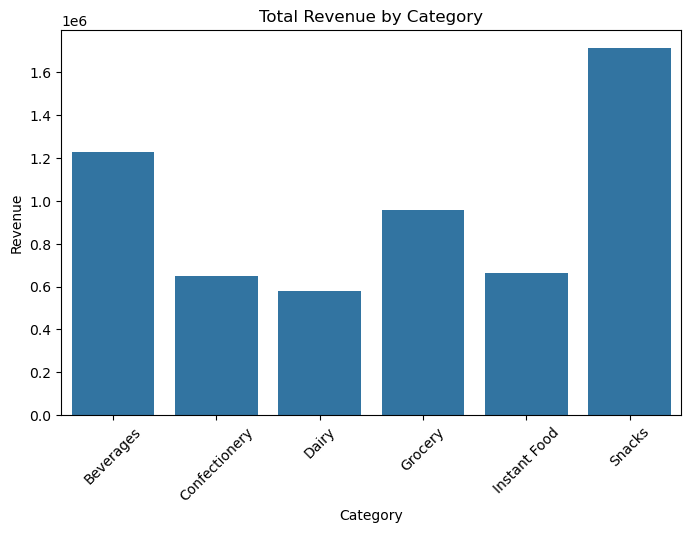

In [21]:
plt.figure(figsize=(8,5))
sns.barplot(x=zep.groupby('Category')['Total_Revenue'].sum().index,
            y=zep.groupby('Category')['Total_Revenue'].sum().values)

plt.title("Total Revenue by Category")
plt.xlabel("Category")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.show()

# Revenue By City

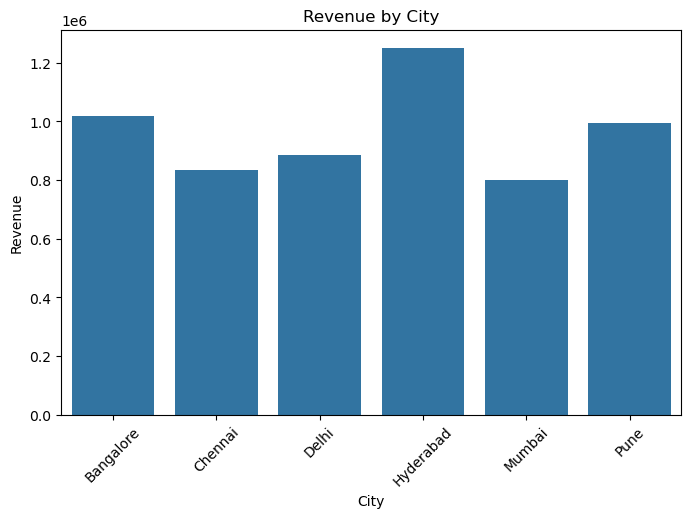

In [22]:
plt.figure(figsize=(8,5))
sns.barplot(x=zep.groupby('City')['Total_Revenue'].sum().index,
            y=zep.groupby('City')['Total_Revenue'].sum().values)

plt.title("Revenue by City")
plt.xlabel("City")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.show()

# Discount VS Revenue

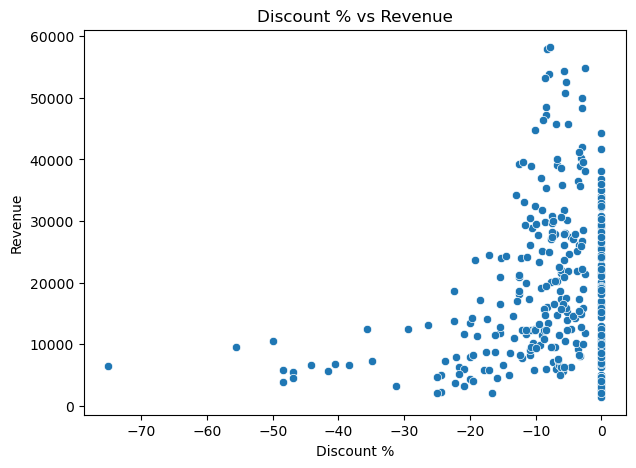

In [23]:
plt.figure(figsize=(7,5))
sns.scatterplot(data=zep, x='Discount_%', y='Total_Revenue')

plt.title("Discount % vs Revenue")
plt.xlabel("Discount %")
plt.ylabel("Revenue")
plt.show()

# Influencer Impact

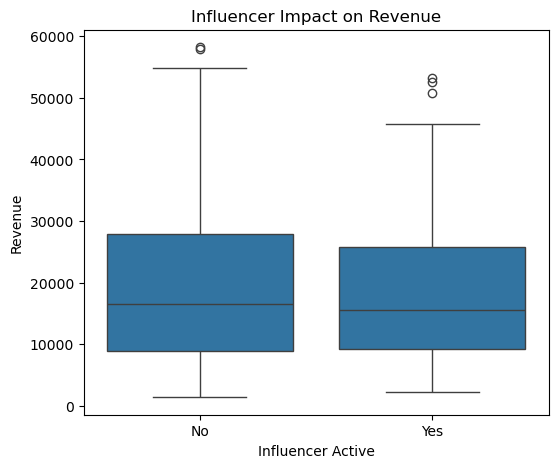

In [24]:
plt.figure(figsize=(6,5))
sns.boxplot(x='Influencer_Active', y='Total_Revenue', data=zep)

plt.title("Influencer Impact on Revenue")
plt.xlabel("Influencer Active")
plt.ylabel("Revenue")
plt.show()

# Distribution Of Orders

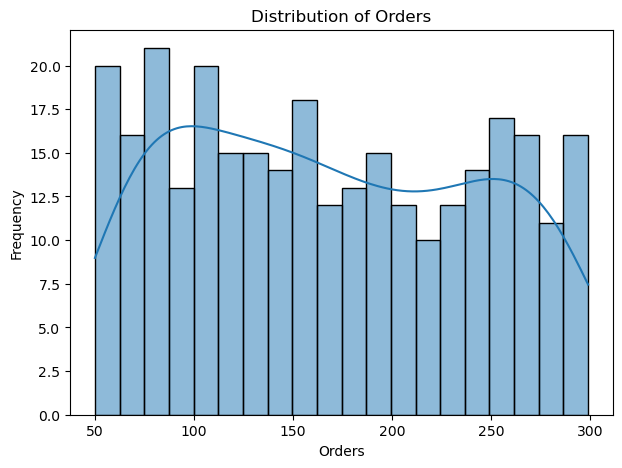

In [26]:
plt.figure(figsize=(7,5))
sns.histplot(zep['Orders'], bins=20, kde=True)

plt.title("Distribution of Orders")
plt.xlabel("Orders")
plt.ylabel("Frequency")
plt.show()

# Correlation Heatmap

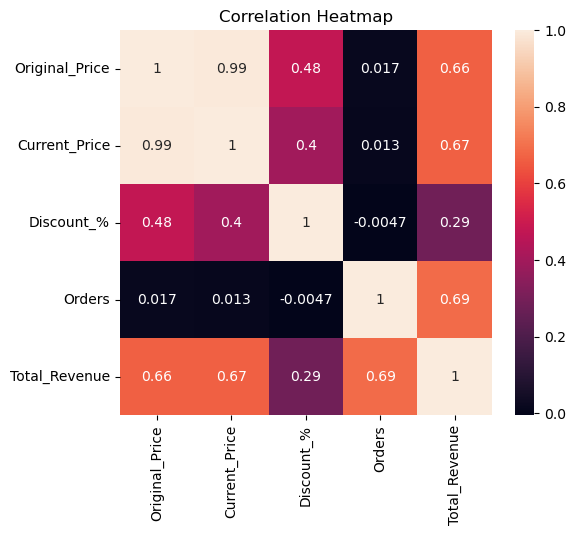

In [27]:
plt.figure(figsize=(6,5))
sns.heatmap(zep[['Original_Price','Current_Price','Discount_%','Orders','Total_Revenue']].corr(),
            annot=True)

plt.title("Correlation Heatmap")
plt.show()

# Top 10 Products

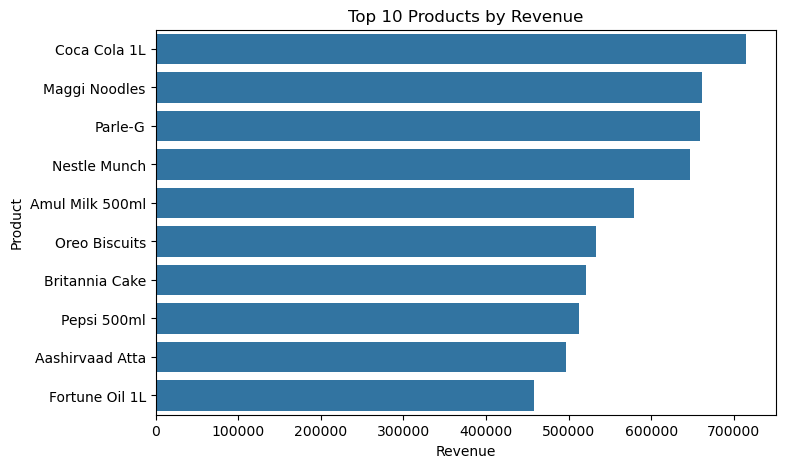

In [28]:
top_products = zep.groupby('Product_Name')['Total_Revenue'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(8,5))
sns.barplot(x=top_products.values, y=top_products.index)

plt.title("Top 10 Products by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Product")
plt.show()

In [30]:
print(zep.columns)

Index(['Product_Name', 'Category', 'City', 'Original_Price', 'Current_Price',
       'Discount', 'Orders', 'Total_Revenue', 'Influencer_Active',
       'Discount_%', 'Revenue_per_order', 'Influencer_flag',
       'Product_Encoded'],
      dtype='object')


In [32]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# 1. Defining Features (X) and Target (y)
# We use the encoded product, the number of orders, and the discount rate
X = zep[['Product_Encoded', 'Orders', 'Discount_%']] 
y = zep['Total_Revenue']

# 2. Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Initialize and Train the Model
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# 4. Make predictions and evaluate
y_pred = model.predict(X_test)

print(f"Model Accuracy (R2 Score): {r2_score(y_test, y_pred):.4f}")
print(f"Average Error (MAE): {mean_absolute_error(y_test, y_pred):.2f}")

Model Accuracy (R2 Score): 0.6373
Average Error (MAE): 6108.68
